# CLIPBench Downstream Results

This notebook generates figures and tables for CLIPBench downstream benchmarks:
1. **Zero-Shot Classification** - ImageNet and Fine-Grained datasets
2. **Image-Text Retrieval** - COCO and Flickr datasets (I2T and T2I recall@1)

Uses functions from `evalviz/downstream.py` for data processing and visualization.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add evalviz to path
sys.path.insert(0, '..')

from evalviz.io import load_results_from_runs, RunSpec
from evalviz.downstream import (
    build_downstream_table,
    build_downstream_summary,
    build_retrieval_combined_table,
    make_latex_downstream_table,
    make_latex_retrieval_table,
    make_latex_downstream_summary_table,
    DOWNSTREAM_GROUPINGS,
    DOWNSTREAM_METRICS,
)
from evalviz.plots.downstream import (
    plot_downstream_bars,
    plot_downstream_comparison,
    plot_downstream_heatmap,
    plot_downstream_radar,
)

# Configure matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

In [3]:
# Optional: Configure for publication-quality figures
try:
    from tueplots import figsizes, fontsizes, fonts
    plt.rcParams.update(figsizes.icml2024_full())
    plt.rcParams.update(fontsizes.icml2024())
    print("Using tueplots ICML 2024 style")
except ImportError:
    print("tueplots not available, using default matplotlib style")

Using tueplots ICML 2024 style


## 1. Configuration

Define which models to compare and their CSV paths.

In [4]:
# =============================================================================
# MODEL CONFIGURATION - Load from config files (same as comp_benchmarks_tables.ipynb)
# =============================================================================

from evalviz.config import load_runs_from_files, load_methods, load_benchmarks

# Load runs from config files
runs = load_runs_from_files(
    "../configs/runs_baselines.json",   # CLIP baseline
    "../configs/runs_external.json",    # NegCLIP, DeGLA, CLoVe, FSC-CLIP, etc.
    "../configs/runs_ours_final.json",  # CS-CLIP (our model)
)

methods = load_methods("../configs/methods.json")
bench_cfg = load_benchmarks("../configs/benchmarks.json")

print(f"Loaded {len(runs)} model runs:")
for run in runs:
    print(f"  - {run.label}: {run.csv_path}")

# Output directories
OUTPUT_DIR = Path("../figures/downstream")
TEX_DIR = Path("../tex_tables")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TEX_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nOutput directory: {OUTPUT_DIR.resolve()}")
print(f"LaTeX directory: {TEX_DIR.resolve()}")

Loaded 19 model runs:
  - CLIP: ../configs/../evaluation/00_baseline_openai_vitb32.csv
  - NegCLIP (COCO): ../configs/../evaluation/negclip_coco_vitb32.csv
  - CE CLIP: ../configs/../evaluation/ce_clip_vitb32.csv
  - CON CLIP: ../configs/../evaluation/con_clip_vitb32.csv
  - FSC CLIP (CC3M): ../configs/../evaluation/fsc_clip_cc3m_vitb32.csv
  - FSC CLIP (COCO): ../configs/../evaluation/fsc_clip_coco_vitb32.csv
  - FSC CLIP (LAION+COCO): ../configs/../evaluation/fsc_clip_laioncoco_vitb32.csv
  - CLIC CogVLM (LAION): ../configs/../evaluation/clic_cogvlm_vitb32_laion.csv
  - CLIC CogVLM (PixPR RedCaps): ../configs/../evaluation/clic_cogvlm_vitb32_pixpr_redcaps.csv
  - READCLIP: ../configs/../evaluation/readclip_vitb32.csv
  - TSVLC: ../configs/../evaluation/tsvlc_vitb32.csv
  - TripletCLIP (CC12M): ../configs/../evaluation/tripletclip_cc12m_vitb12.csv
  - DAC (LLM): ../configs/../evaluation/dac_vitb32_llm.csv
  - DAC (SAM): ../configs/../evaluation/dac_vitb32_sam.csv
  - LaCLIP (CC12M): .

In [5]:
# =============================================================================
# LOAD DATA (same pattern as comp_benchmarks_tables.ipynb)
# =============================================================================

from evalviz.preprocess import apply_mappings, add_dataset_type_columns, apply_dataset_merge_rules
from evalviz.enrich import attach_method_metadata, attach_benchmark_metadata

# Load and preprocess data
# Use text_contrastive_accuracy (I2T compositionality) for checkpoint selection
# to match the checkpoint selection used in comp_benchmarks_tables.ipynb
df = load_results_from_runs(runs, metric_for_step_selection="text_contrastive_accuracy")
df = apply_dataset_merge_rules(df, bench_cfg)
df = apply_mappings(df, bench_cfg)
df = add_dataset_type_columns(df)
df = attach_method_metadata(df, methods)
df = attach_benchmark_metadata(df, bench_cfg)

print(f"Loaded {len(df)} rows")
print(f"Models: {df['run_label'].unique().tolist()}")
print(f"Datasets: {sorted(df['dataset'].unique().tolist())[:15]}...")
print(f"Benchmark types: {df['benchmark_type'].unique().tolist() if 'benchmark_type' in df.columns else 'N/A'}")

Loaded 6109 rows
Models: ['NegCLIP (COCO)', 'FSC CLIP (LAION+COCO)', 'READCLIP', 'DAC (SAM)', 'DAC (LLM)', 'CE CLIP', 'LaCLIP (CC12M)', 'CS-CLIP', 'FSC CLIP (CC3M)', 'TripletCLIP (CC12M)', 'FSC CLIP (COCO)', 'LabCLIP', 'CON CLIP', 'CLIC CogVLM (PixPR RedCaps)', 'DeGLA', 'CLIC CogVLM (LAION)', 'CLIP', 'CLoVe', 'TSVLC']
Datasets: ['ARO', 'BLA', 'CLIPBench', 'COCO-CF', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VL_CheckList']...
Benchmark types: ['compositional', 'downstream_clipbench']


In [6]:
# =============================================================================
# DEBUG: Check which step is selected for CS-CLIP and compare retrieval values
# =============================================================================

# Load raw CSV to check available steps
csclip_csv = "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv"
df_raw = pd.read_csv(csclip_csv)

# Convert value to numeric early
df_raw['value'] = pd.to_numeric(df_raw['value'], errors='coerce')

print("=== DEBUG: CS-CLIP Checkpoint Selection ===")
print(f"\nAvailable steps: {sorted(df_raw['step'].dropna().unique())}")

# Check retrieval values at each step
retrieval_metrics = ['text_retrieval_recall@1', 'image_retrieval_recall@1']
retrieval_subsets = ['wds_mscoco_captions', 'wds_flickr8k']

print("\n--- Retrieval values per step (COCO & Flickr8k) ---")
for step in sorted(df_raw['step'].dropna().unique()):
    if step == 0:
        continue
    step_df = df_raw[df_raw['step'] == step]
    print(f"\nStep {int(step)}:")
    for subset in retrieval_subsets:
        for metric in retrieval_metrics:
            val = step_df[(step_df['subset'] == subset) & (step_df['metric'] == metric)]['value']
            if len(val) > 0 and pd.notna(val.values[0]):
                print(f"  {subset} / {metric}: {float(val.values[0])*100:.1f}%")

# Check which step load_results_from_runs would select
print("\n--- Checkpoint selection logic ---")
non_zero_steps = [s for s in df_raw['step'].dropna().unique() if s != 0]
df_sel = df_raw[df_raw['step'].isin(non_zero_steps)]

# Using text_contrastive_accuracy
text_scores = df_sel[df_sel['metric'] == 'text_contrastive_accuracy'].groupby('step')['value'].mean()
print(f"\ntext_contrastive_accuracy avg per step:")
for step, score in text_scores.sort_index().items():
    print(f"  Step {int(step)}: {score*100:.2f}%")
print(f"  -> Best step (by I2T): {int(text_scores.idxmax())}")

# Check what step was actually selected in df
csclip_df = df[df['run_label'] == 'CS-CLIP']
if 'step' in csclip_df.columns:
    selected_step = csclip_df['step'].unique()
    print(f"\nActually selected step in df: {selected_step}")

# Show the retrieval values in the loaded df
print("\n--- Retrieval values in loaded df (CS-CLIP) ---")
for subset in retrieval_subsets:
    for metric in retrieval_metrics:
        val = csclip_df[(csclip_df['subset'] == subset) & (csclip_df['metric'] == metric)]['value']
        if len(val) > 0 and pd.notna(val.values[0]):
            print(f"  {subset} / {metric}: {float(val.values[0])*100:.1f}%")

=== DEBUG: CS-CLIP Checkpoint Selection ===

Available steps: [np.int64(0), np.int64(2500), np.int64(5000), np.int64(7500), np.int64(10000), np.int64(12500), np.int64(15000), np.int64(17500), np.int64(20000)]

--- Retrieval values per step (COCO & Flickr8k) ---

Step 2500:
  wds_mscoco_captions / text_retrieval_recall@1: 60.0%
  wds_mscoco_captions / image_retrieval_recall@1: 43.7%
  wds_flickr8k / text_retrieval_recall@1: 80.3%
  wds_flickr8k / image_retrieval_recall@1: 66.3%

Step 5000:
  wds_mscoco_captions / text_retrieval_recall@1: 61.0%
  wds_mscoco_captions / image_retrieval_recall@1: 45.1%
  wds_flickr8k / text_retrieval_recall@1: 80.0%
  wds_flickr8k / image_retrieval_recall@1: 67.3%

Step 7500:
  wds_mscoco_captions / text_retrieval_recall@1: 62.2%
  wds_mscoco_captions / image_retrieval_recall@1: 45.7%
  wds_flickr8k / text_retrieval_recall@1: 80.7%
  wds_flickr8k / image_retrieval_recall@1: 66.9%

Step 10000:
  wds_mscoco_captions / text_retrieval_recall@1: 61.9%
  wds_msco

In [7]:
# =============================================================================
# FILTER MODELS (Optional)
# =============================================================================
# Uncomment to filter to specific models of interest

# Option 1: Keep only specific models
# MODELS_TO_KEEP = ["CLIP", "NegCLIP (COCO)", "CS-CLIP", "DeGLA", "CLoVe", "FSC CLIP (COCO)"]
# df = df[df["run_label"].isin(MODELS_TO_KEEP)]

# Option 2: Exclude specific models  
# MODELS_TO_EXCLUDE = ["TSVLC", "CE CLIP", "CON CLIP"]
# df = df[~df["run_label"].isin(MODELS_TO_EXCLUDE)]

# Show available models with their metadata
print("Available models in dataset:")
model_info = df.groupby("run_label").first()[["is_baseline", "is_ours", "is_pretrained"]].fillna(False)
display(model_info)

Available models in dataset:


,is_baseline,is_ours,is_pretrained
run_label,,,
CE CLIP,False,False,False
CLIC CogVLM (LAION),False,False,False
CLIC CogVLM (PixPR RedCaps),False,False,False
CLIP,True,False,False
CLoVe,False,False,False
CON CLIP,False,False,False
CS-CLIP,False,True,False
DAC (LLM),False,False,False
DAC (SAM),False,False,False


## 2. Zero-Shot Classification Results

In [8]:
# =============================================================================
# ZERO-SHOT CLASSIFICATION TABLE
# =============================================================================

# Build pivot table for zero-shot classification
zs_pivot, zs_run_info = build_downstream_table(
    df, 
    task="zero_shot_classification", 
    metric="acc1"
)

if not zs_pivot.empty:
    print("Zero-Shot Classification Results (acc1 × 100):")
    display((zs_pivot * 100).round(1))
    
    # Show groupings
    print("\nDataset groupings:")
    for group_name, datasets in DOWNSTREAM_GROUPINGS.get("zero_shot_classification", {}).items():
        present = [d for d in datasets if d in zs_pivot.columns]
        print(f"  {group_name}: {present}")
else:
    print("No zero-shot classification data found.")

Zero-Shot Classification Results (acc1 × 100):


subset,wds_imagenet-o,wds_imagenet1k,wds_imagenet_sketch,wds_imagenetv2,wds_sun397,wds_vtab-caltech101,wds_vtab-cifar10
run_label,,,,,,,
CE CLIP,44.9,49.9,31.5,43.3,56.6,78.4,85.9
CLIC CogVLM (LAION),46.8,61.7,41.4,55.0,64.3,81.8,89.5
CLIC CogVLM (PixPR RedCaps),47.2,62.3,41.8,55.3,64.2,82.4,89.8
CLIP,50.7,60.2,46.4,52.4,65.0,81.9,88.4
CLoVe,41.6,52.9,35.5,46.6,60.2,78.6,88.4
CON CLIP,47.0,63.2,42.8,55.5,63.9,82.5,90.7
CS-CLIP,43.4,58.9,38.0,51.7,57.4,81.5,88.7
DAC (LLM),43.7,52.7,35.5,46.3,56.3,79.3,87.0
DAC (SAM),44.0,52.9,35.3,46.8,55.1,78.8,86.7



Dataset groupings:
  ImageNet: ['wds_imagenet1k', 'wds_imagenetv2', 'wds_imagenet_sketch', 'wds_imagenet-o']
  Fine-Grained: ['wds_vtab-caltech101', 'wds_vtab-cifar10', 'wds_sun397']


/mnt/lustre/work/oh/owl336/LabCLIP_v2/CLIP-not-BoW-unimodally/experiments/fig_notebooks/../evalviz/plots/downstream.py:114: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved plot to: ../figures/downstream/zero_shot_classification_bars.pdf


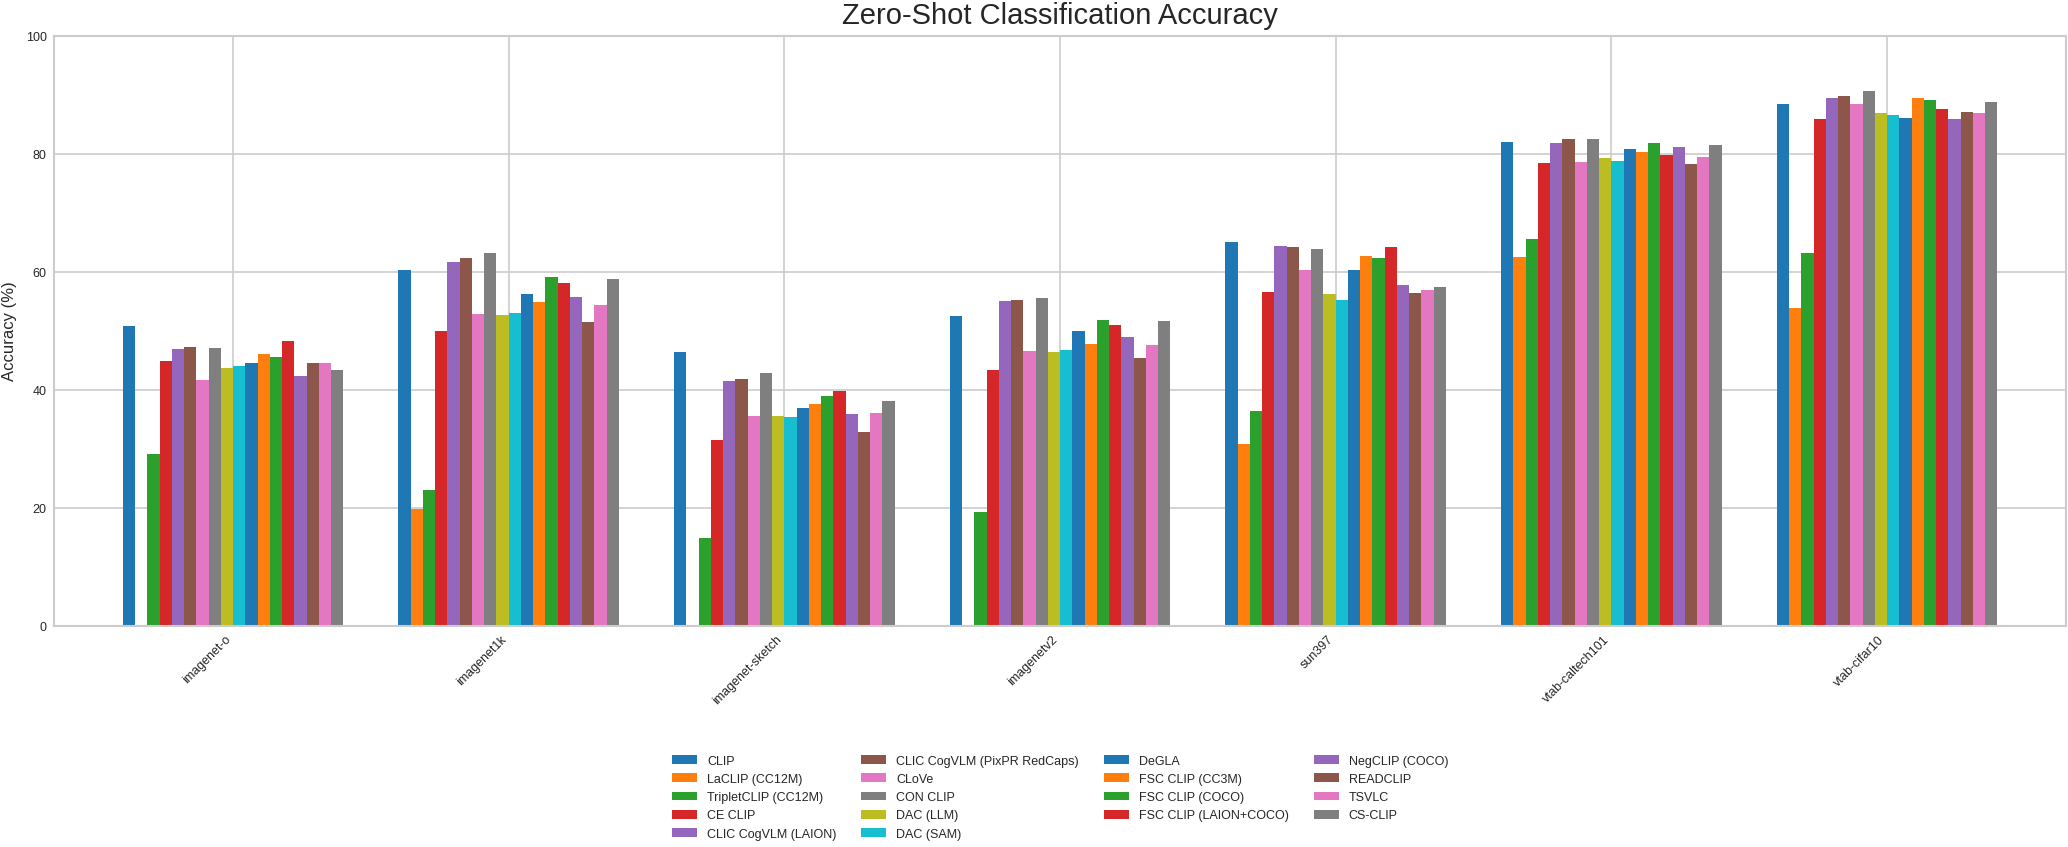

In [9]:
# =============================================================================
# ZERO-SHOT CLASSIFICATION BAR PLOT
# =============================================================================

if not zs_pivot.empty:
    plot_downstream_bars(
        df,
        task="zero_shot_classification",
        title="Zero-Shot Classification Accuracy",
        figsize=(14, 6),
        ylim=(0, 100),
        save_path=OUTPUT_DIR / "zero_shot_classification_bars.pdf",
    )

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

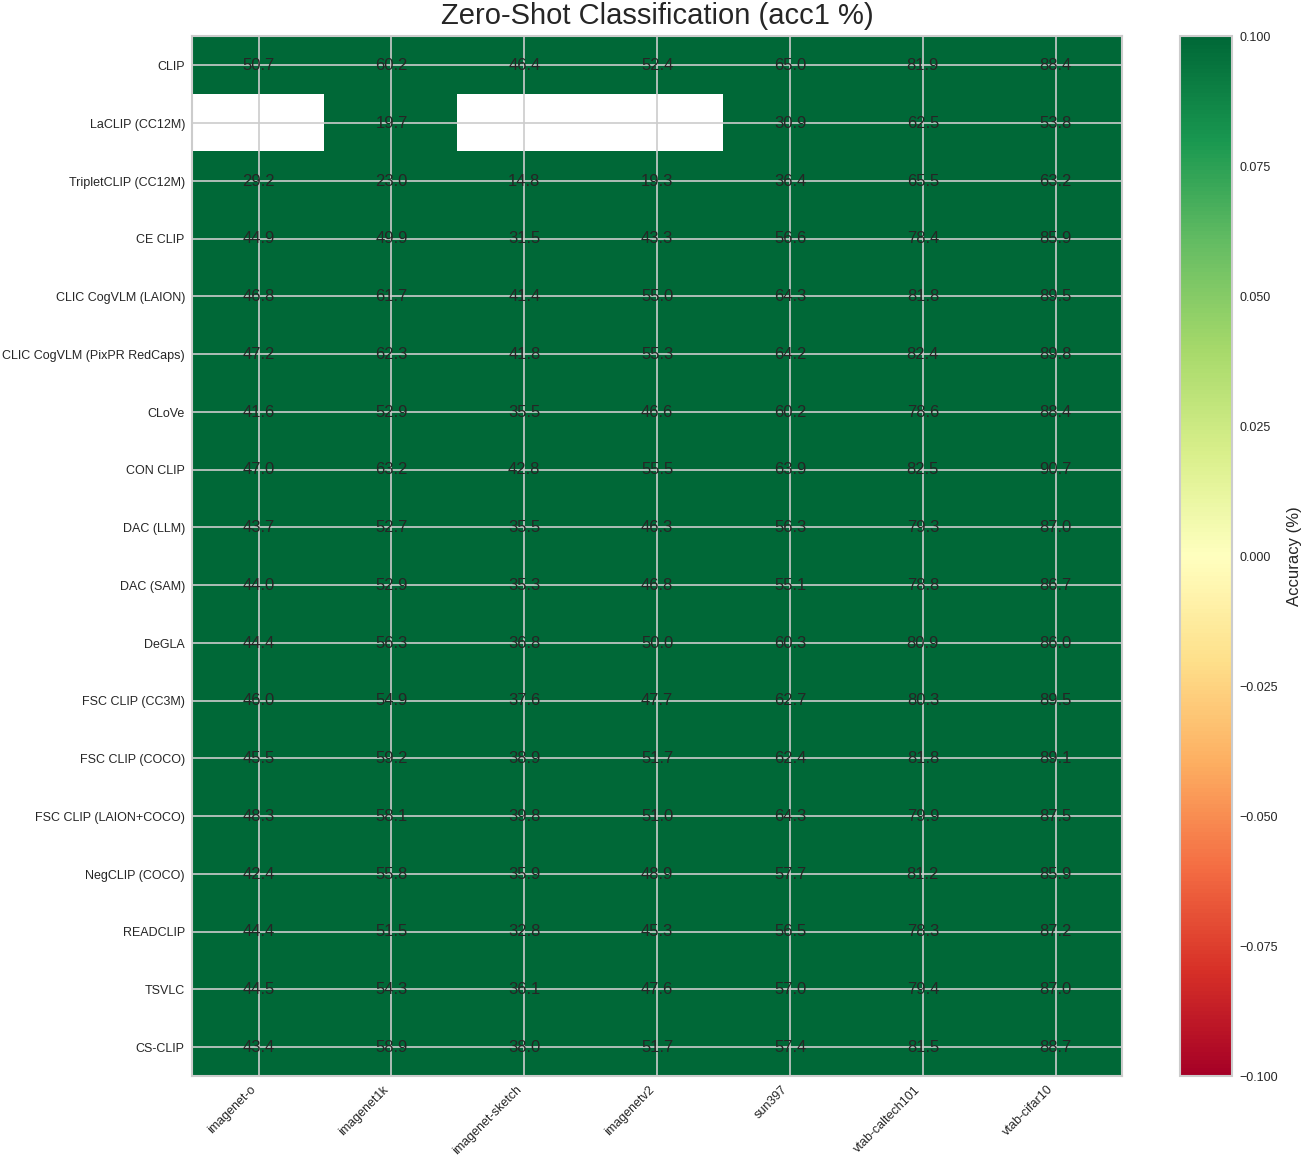

In [10]:
# =============================================================================
# ZERO-SHOT CLASSIFICATION HEATMAP
# =============================================================================

if not zs_pivot.empty:
    plot_downstream_heatmap(
        df,
        task="zero_shot_classification",
        title="Zero-Shot Classification (acc1 %)",
        cmap="RdYlGn",
        save_path=OUTPUT_DIR / "zero_shot_classification_heatmap.pdf",
    )

In [13]:
# =============================================================================
# LATEX TABLE: ZERO-SHOT CLASSIFICATION
# =============================================================================

if not zs_pivot.empty:
    latex_zs = make_latex_downstream_table(
        df,
        task="zero_shot_classification",
        caption="Zero-shot classification accuracy (\\%). Best per column in \\textbf{bold}.",
        label="tab:downstream_zs",
        save_path=TEX_DIR / "downstream_zero_shot.tex",
        metric="acc5"
    )
    print(latex_zs)

Saved to: ../tex_tables/downstream_zero_shot.tex
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Zero-shot classification accuracy (\%). Best per column in \textbf{bold}.}
  \label{tab:downstream_zs}
  \begin{adjustbox}{max width=\textwidth}
  \setlength{\tabcolsep}{3pt}
  \begin{tabular}{lcccccccc}
    \toprule
     & \multicolumn{4}{c}{ImageNet} & \multicolumn{3}{c}{Fine-Grained} &  \\
    \cmidrule(lr){2-5} \cmidrule(lr){6-8}
    Model & imagenet1k & imagenetv2 & imagenet-sketch & imagenet-o & vtab-caltech101 & vtab-cifar10 & sun397 & Avg \\
    \midrule
    CLIP & \underline{85.9} & \underline{79.4} & \underline{\textbf{72.6}} & \underline{\textbf{82.3}} & \underline{94.1} & \underline{99.7} & \underline{91.7} & \underline{86.5} \\
    \midrule
    LaCLIP (CC12M) & 41.4 & -- & -- & -- & 85.9 & 90.3 & 61.1 & 69.7 \\
    TripletCLIP (CC12M) & 46.9 & 42.2 & 33.3 & 57.8 & 89.1 & 95.5 & 68.5 & 61.9 \\
    \midrule
    CE CLIP & 80.5 & 74.3 & 58.6 & 74.8 & 94.6 & 98.7 & 87.5 & 81.

## 3. Image-Text Retrieval Results

In [14]:
# =============================================================================
# RETRIEVAL TABLE (T2I - Text-to-Image)
# =============================================================================

t2i_pivot, t2i_run_info = build_downstream_table(
    df, 
    task="retrieval_t2i", 
    metric="text_retrieval_recall@1"
)

if not t2i_pivot.empty:
    print("Text-to-Image Retrieval Results (R@1 × 100):")
    display((t2i_pivot * 100).round(1))
else:
    print("No T2I retrieval data found.")

Text-to-Image Retrieval Results (R@1 × 100):


subset,wds_flickr8k,wds_mscoco_captions
run_label,,
CE CLIP,67.8,56.1
CLIC CogVLM (LAION),68.3,47.6
CLIC CogVLM (PixPR RedCaps),70.8,47.1
CLIP,72.9,52.5
CLoVe,64.0,46.3
CON CLIP,70.0,49.1
CS-CLIP,81.5,61.9
DAC (LLM),66.7,46.0
DAC (SAM),66.5,45.9


In [15]:
# =============================================================================
# RETRIEVAL TABLE (I2T - Image-to-Text)
# =============================================================================

i2t_pivot, i2t_run_info = build_downstream_table(
    df, 
    task="retrieval_i2t", 
    metric="image_retrieval_recall@1"
)

if not i2t_pivot.empty:
    print("Image-to-Text Retrieval Results (R@1 × 100):")
    display((i2t_pivot * 100).round(1))
else:
    print("No I2T retrieval data found.")

Image-to-Text Retrieval Results (R@1 × 100):


subset,wds_flickr8k,wds_mscoco_captions
run_label,,
CE CLIP,64.8,47.1
CLIC CogVLM (LAION),56.5,34.6
CLIC CogVLM (PixPR RedCaps),56.1,34.5
CLIP,56.2,34.3
CLoVe,58.8,37.3
CON CLIP,56.6,30.9
CS-CLIP,67.3,46.3
DAC (LLM),53.5,30.3
DAC (SAM),52.0,29.8


In [16]:
# =============================================================================
# COMBINED RETRIEVAL TABLE (I2T + T2I)
# =============================================================================

retrieval_pivot, retrieval_run_info = build_retrieval_combined_table(df)

if not retrieval_pivot.empty:
    print("Combined Retrieval Results (R@1 × 100):")
    display((retrieval_pivot * 100).round(1))
else:
    print("No retrieval data found.")

Combined Retrieval Results (R@1 × 100):


subset                      wds_flickr8k       wds_mscoco_captions      
metric_short                         I2T   T2I                 I2T   T2I
run_label                                                               
CE CLIP                             64.8  67.8                47.1  56.1
CLIC CogVLM (LAION)                 56.5  68.3                34.6  47.6
CLIC CogVLM (PixPR RedCaps)         56.1  70.8                34.5  47.1
CLIP                                56.2  72.9                34.3  52.5
CLoVe                               58.8  64.0                37.3  46.3
CON CLIP                            56.6  70.0                30.9  49.1
CS-CLIP                             67.3  81.5                46.3  61.9
DAC (LLM)                           53.5  66.7                30.3  46.0
DAC (SAM)                           52.0  66.5                29.8  45.9
DeGLA                               65.3  70.2                43.2  50.9
FSC CLIP (CC3M)                     63.6  70.0                40.9  47.6
FSC CLIP (COCO)                     67.0  79.2                46.0  60.4
FSC CLIP (LAION+COCO)               63.2  68.8                40.4  49.6
LaCLIP (CC12M)                      16.4  22.2                 7.2  10.5
NegCLIP (COCO)                      63.9  75.6                41.5  56.2
READCLIP                            66.6  75.6                47.1  60.3
TSVLC                               51.6  66.1                29.8  45.9
TripletCLIP (CC12M)                 23.4  28.4                11.3  14.9

/mnt/lustre/work/oh/owl336/LabCLIP_v2/CLIP-not-BoW-unimodally/experiments/fig_notebooks/../evalviz/plots/downstream.py:114: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved plot to: ../figures/downstream/retrieval_t2i_bars.pdf


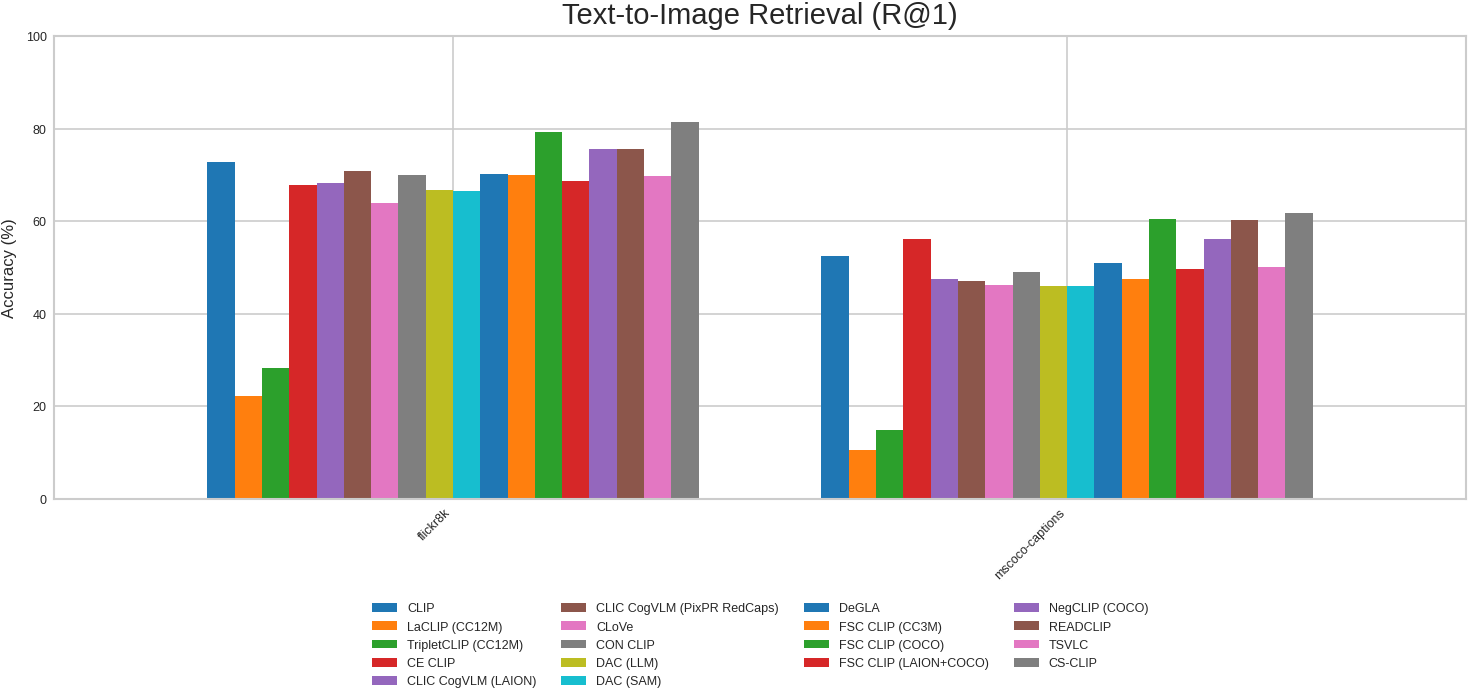

/mnt/lustre/work/oh/owl336/LabCLIP_v2/CLIP-not-BoW-unimodally/experiments/fig_notebooks/../evalviz/plots/downstream.py:114: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved plot to: ../figures/downstream/retrieval_i2t_bars.pdf


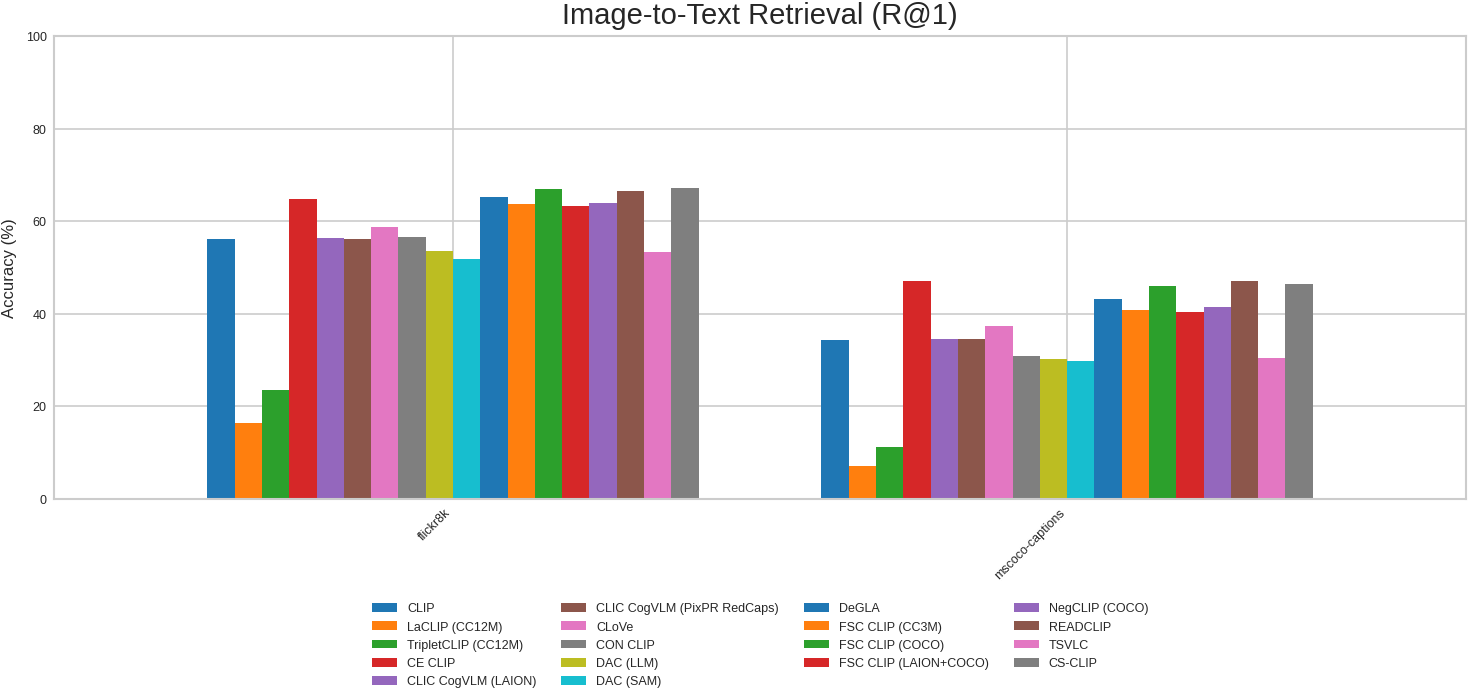

In [15]:
# =============================================================================
# RETRIEVAL BAR PLOTS
# =============================================================================

if not t2i_pivot.empty:
    plot_downstream_bars(
        df,
        task="retrieval_t2i",
        title="Text-to-Image Retrieval (R@1)",
        figsize=(10, 5),
        ylim=(0, 100),
        save_path=OUTPUT_DIR / "retrieval_t2i_bars.pdf",
    )

if not i2t_pivot.empty:
    plot_downstream_bars(
        df,
        task="retrieval_i2t",
        title="Image-to-Text Retrieval (R@1)",
        figsize=(10, 5),
        ylim=(0, 100),
        save_path=OUTPUT_DIR / "retrieval_i2t_bars.pdf",
    )

In [17]:
# =============================================================================
# LATEX TABLE: COMBINED RETRIEVAL
# =============================================================================

if not retrieval_pivot.empty:
    latex_retrieval = make_latex_retrieval_table(
        df,
        caption="Image-text retrieval results (Recall@1 \\%). I2T = Image-to-Text, T2I = Text-to-Image. Best per column in \\textbf{bold}.",
        label="tab:downstream_retrieval",
        save_path=TEX_DIR / "downstream_retrieval.tex",
    )
    print(latex_retrieval)

Saved to: ../tex_tables/downstream_retrieval.tex
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Image-text retrieval results (Recall@1 \%). I2T = Image-to-Text, T2I = Text-to-Image. Best per column in \textbf{bold}.}
  \label{tab:downstream_retrieval}
  \begin{adjustbox}{max width=\textwidth}
  \setlength{\tabcolsep}{3pt}
  \begin{tabular}{lcccccc}
    \toprule
     & \multicolumn{2}{c}{flickr8k} & \multicolumn{2}{c}{mscoco captions} & \multicolumn{2}{c}{Average} \\
    \cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7}
    Model & I2T & T2I & I2T & T2I & I2T & T2I \\
    \midrule
    CLIP & \underline{56.2} & \underline{72.9} & \underline{34.3} & \underline{52.5} & \underline{45.2} & \underline{62.7} \\
    \midrule
    LaCLIP (CC12M) & 16.4 & 22.2 & 7.2 & 10.5 & 11.8 & 16.3 \\
    TripletCLIP (CC12M) & 23.4 & 28.4 & 11.3 & 14.9 & 17.3 & 21.7 \\
    \midrule
    CE CLIP & 64.8 & 67.8 & \textbf{47.1} & 56.1 & 55.9 & 61.9 \\
    CLIC CogVLM (LAION) & 56.5 & 68.3 & 34.6 & 4

## 4. Summary Table (All Downstream Tasks)

In [21]:
# =============================================================================
# DOWNSTREAM SUMMARY TABLE
# =============================================================================

summary_pivot, summary_run_info = build_downstream_summary(df)

if not summary_pivot.empty:
    print("Downstream Summary (averaged per category × 100):")
    display((summary_pivot * 100).round(1))
    
    # Add overall average column
    summary_with_avg = summary_pivot.copy()
    summary_with_avg["Overall"] = summary_pivot.mean(axis=1)
    print("\nWith Overall Average:")
    display((summary_with_avg * 100).round(1))
else:
    print("No downstream summary data found.")

Downstream Summary (averaged per category × 100):


category,Retrieval-I2T,Retrieval-T2I,ZS-Fine-Grained,ZS-ImageNet,ZS-Overall
run_label,,,,,
CE CLIP,55.9,61.9,73.6,42.4,55.8
CLIC CogVLM (LAION),45.5,57.9,78.6,51.2,62.9
CLIC CogVLM (PixPR RedCaps),45.3,58.9,78.8,51.7,63.3
CLIP,45.2,62.7,78.5,52.5,63.6
CLoVe,48.1,55.2,75.7,44.1,57.7
CON CLIP,43.7,59.5,79.1,52.1,63.7
CS-CLIP,56.8,71.7,75.9,48.0,59.9
DAC (LLM),41.9,56.3,74.2,44.6,57.3
DAC (SAM),40.9,56.2,73.5,44.8,57.1



With Overall Average:


category,Retrieval-I2T,Retrieval-T2I,ZS-Fine-Grained,ZS-ImageNet,ZS-Overall,Overall
run_label,,,,,,
CE CLIP,55.9,61.9,73.6,42.4,55.8,57.9
CLIC CogVLM (LAION),45.5,57.9,78.6,51.2,62.9,59.2
CLIC CogVLM (PixPR RedCaps),45.3,58.9,78.8,51.7,63.3,59.6
CLIP,45.2,62.7,78.5,52.5,63.6,60.5
CLoVe,48.1,55.2,75.7,44.1,57.7,56.2
CON CLIP,43.7,59.5,79.1,52.1,63.7,59.6
CS-CLIP,56.8,71.7,75.9,48.0,59.9,62.5
DAC (LLM),41.9,56.3,74.2,44.6,57.3,54.8
DAC (SAM),40.9,56.2,73.5,44.8,57.1,54.5


/mnt/lustre/work/oh/owl336/LabCLIP_v2/CLIP-not-BoW-unimodally/experiments/fig_notebooks/../evalviz/plots/downstream.py:391: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved plot to: ../figures/downstream/downstream_radar.pdf


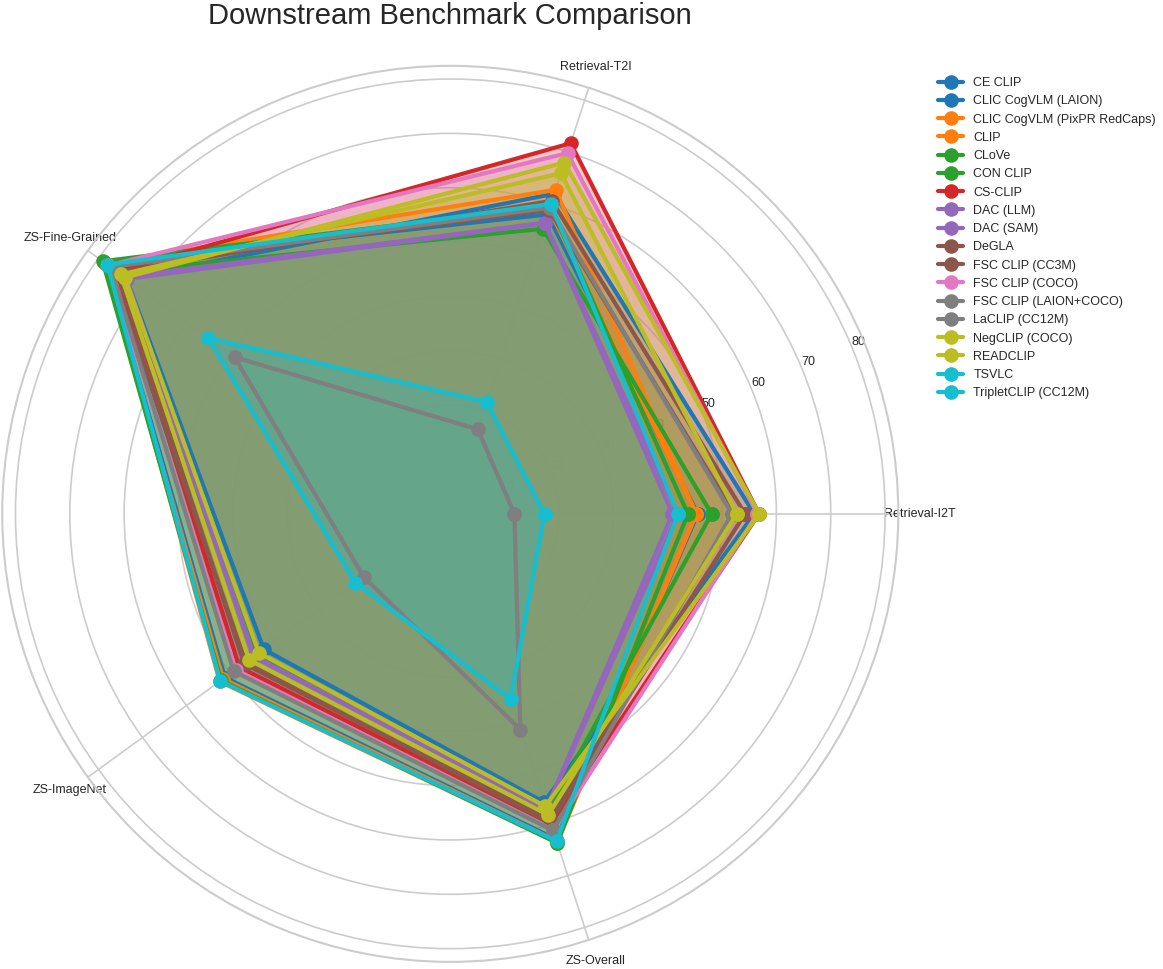

In [12]:
# =============================================================================
# RADAR PLOT: DOWNSTREAM SUMMARY
# =============================================================================

if not summary_pivot.empty:
    plot_downstream_radar(
        df,
        title="Downstream Benchmark Comparison",
        figsize=(8, 8),
        save_path=OUTPUT_DIR / "downstream_radar.pdf",
    )

/mnt/lustre/work/oh/owl336/LabCLIP_v2/CLIP-not-BoW-unimodally/experiments/fig_notebooks/../evalviz/plots/downstream.py:198: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved plot to: ../figures/downstream/downstream_improvement.pdf


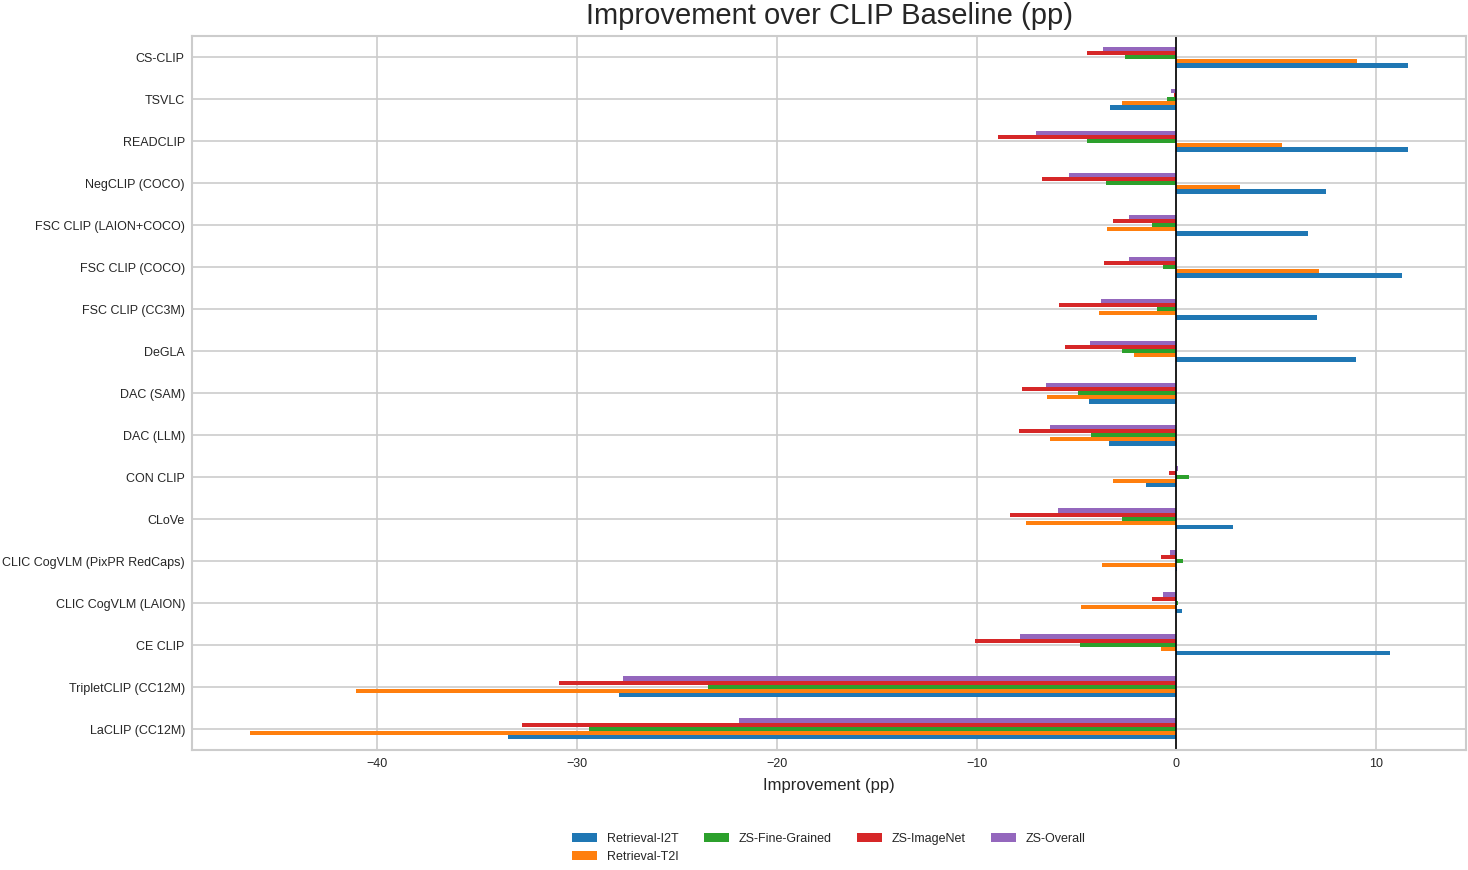

In [13]:
# =============================================================================
# IMPROVEMENT OVER BASELINE
# =============================================================================

if not summary_pivot.empty:
    plot_downstream_comparison(
        df,
        title="Improvement over CLIP Baseline (pp)",
        figsize=(10, 6),
        save_path=OUTPUT_DIR / "downstream_improvement.pdf",
    )

In [14]:
# =============================================================================
# LATEX TABLE: DOWNSTREAM SUMMARY
# =============================================================================

if not summary_pivot.empty:
    latex_summary = make_latex_downstream_summary_table(
        df,
        caption="Summary of downstream benchmark results (\\%). Best per column in \\textbf{bold}.",
        label="tab:downstream_summary",
        save_path=TEX_DIR / "downstream_summary.tex",
    )
    print(latex_summary)

Saved to: ../tex_tables/downstream_summary.tex
\begin{table}[t]
  \centering
  \small
  \caption{Summary of downstream benchmark results (\%). Best per column in \textbf{bold}.}
  \label{tab:downstream_summary}
  \setlength{\tabcolsep}{4pt}
  \begin{tabular}{lcccccc}
    \toprule
    Model & Retrieval-I2T & Retrieval-T2I & ZS-Fine-Grained & ZS-ImageNet & ZS-Overall & Overall \\
    \midrule
    CLIP & \underline{45.2} & \underline{62.7} & \underline{78.5} & \underline{\textbf{52.5}} & \underline{63.6} & \underline{60.5} \\
    \midrule
    LaCLIP (CC12M) & 11.8 & 16.3 & 49.1 & 19.7 & 41.7 & 27.7 \\
    TripletCLIP (CC12M) & 17.3 & 21.7 & 55.0 & 21.6 & 35.9 & 30.3 \\
    \midrule
    CE CLIP & 55.9 & 61.9 & 73.6 & 42.4 & 55.8 & 57.9 \\
    CLIC CogVLM (LAION) & 45.5 & 57.9 & 78.6 & 51.2 & 62.9 & 59.2 \\
    CLIC CogVLM (PixPR RedCaps) & 45.3 & 58.9 & 78.8 & 51.7 & 63.3 & 59.6 \\
    CLoVe & 48.1 & 55.2 & 75.7 & 44.1 & 57.7 & 56.2 \\
    CON CLIP & 43.7 & 59.5 & \textbf{79.1} & 52.1 & \t

## 5. Custom Publication Figure

Create a combined figure for the paper with zero-shot and retrieval side by side.

/tmp/ipykernel_1945562/3447457042.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved to: ../figures/downstream/downstream_combined.pdf


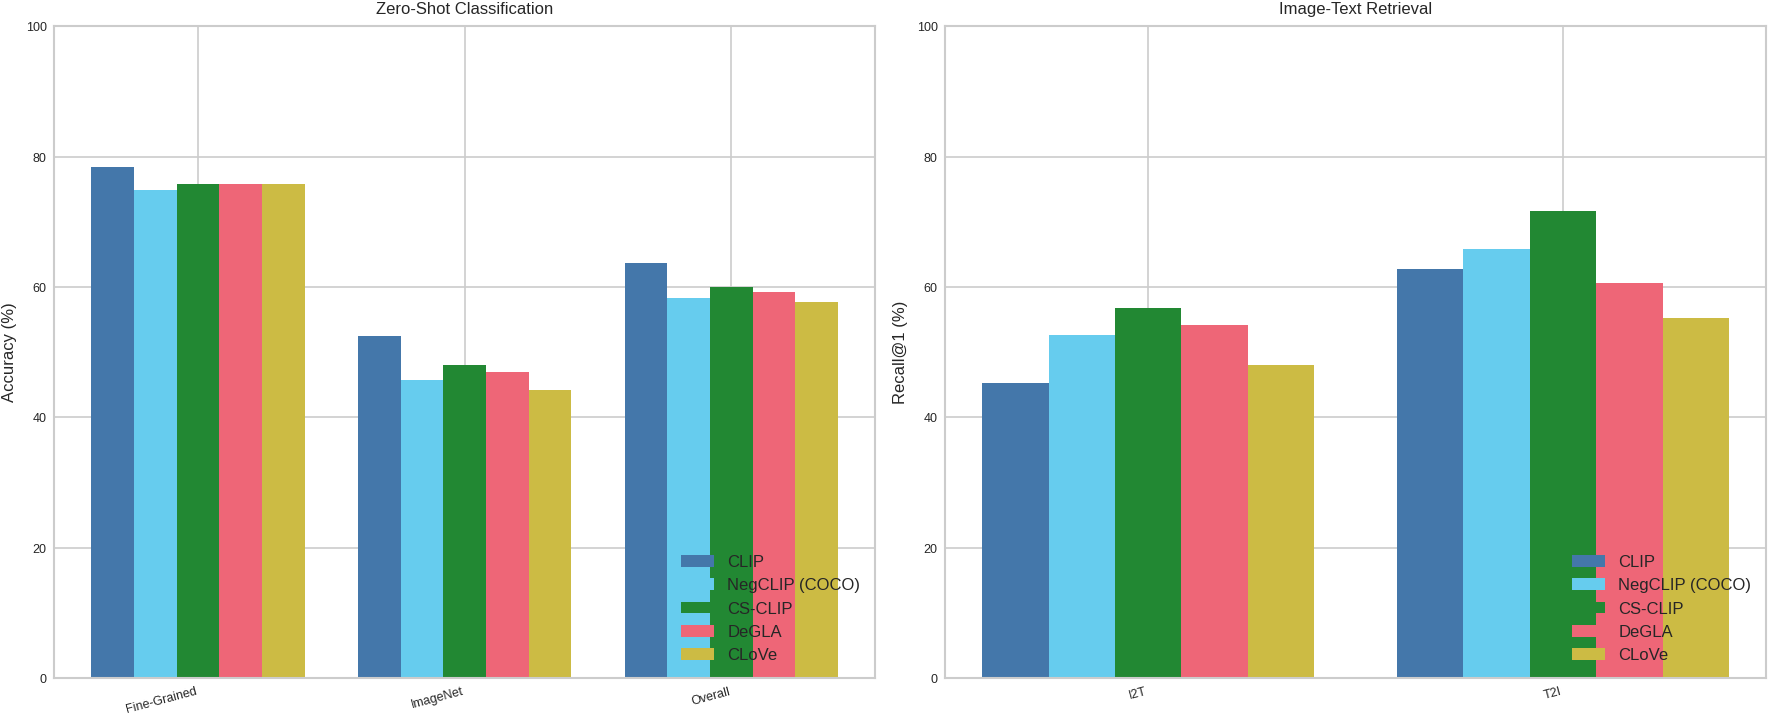


--- All models ---


/tmp/ipykernel_1945562/3447457042.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved to: ../figures/downstream/downstream_combined_all.pdf


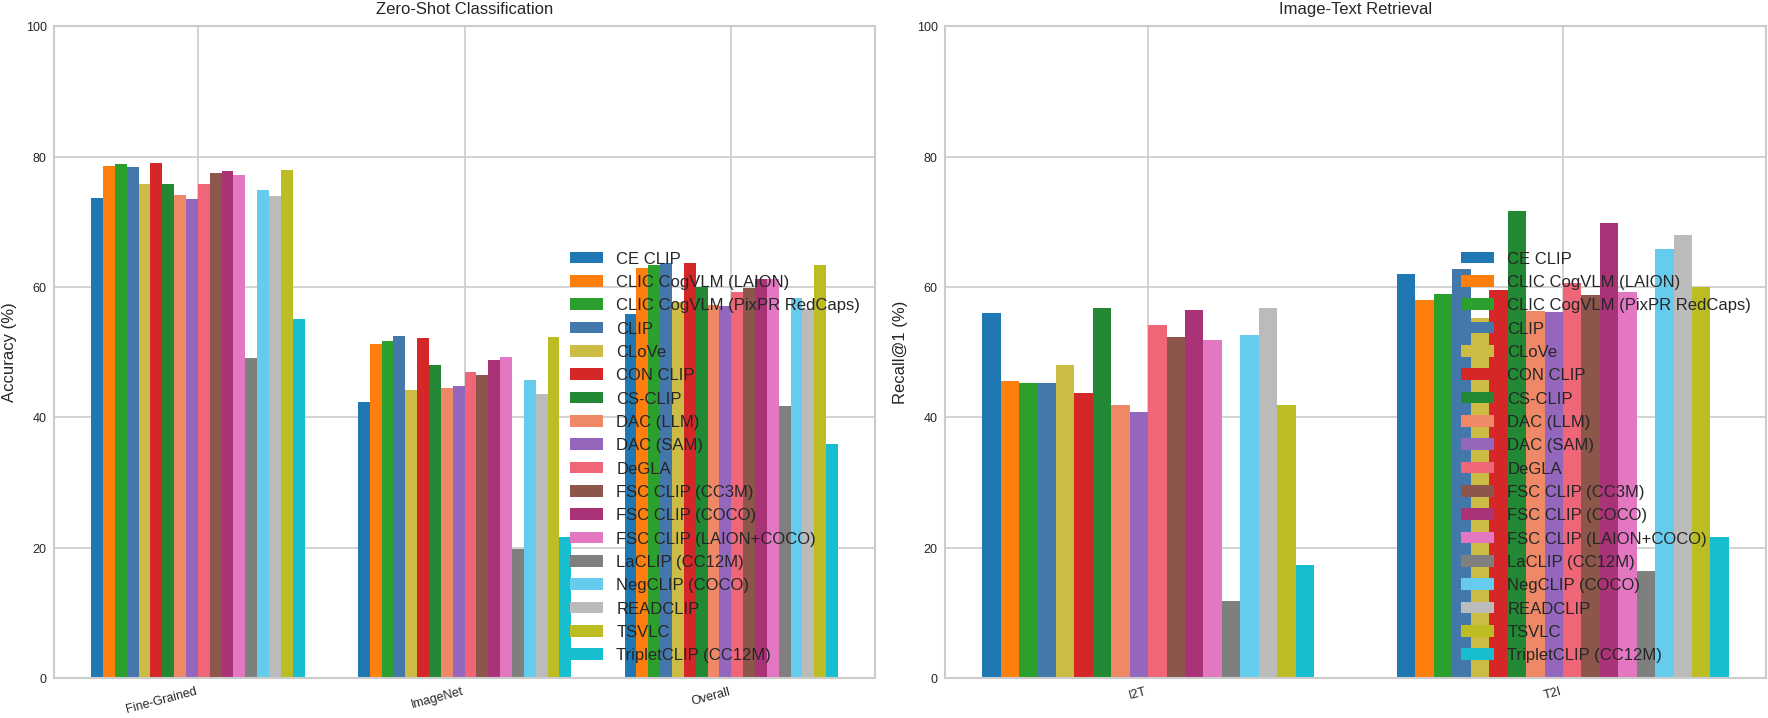

In [15]:
# =============================================================================
# CUSTOM COMBINED FIGURE
# =============================================================================

def create_downstream_combined_figure(df, save_path=None, models_to_show=None):
    """Create a combined figure with zero-shot and retrieval results.
    
    Parameters
    ----------
    df : pd.DataFrame
        Results DataFrame
    save_path : str | Path, optional
        Save plot to file
    models_to_show : list, optional
        Subset of models to show (default: all)
    """
    
    # Get summary data
    summary_pivot, run_info = build_downstream_summary(df)
    
    if summary_pivot.empty:
        print("No data for combined figure.")
        return
    
    # Filter models if specified
    if models_to_show:
        available = [m for m in models_to_show if m in summary_pivot.index]
        summary_pivot = summary_pivot.loc[available]
    
    # Convert to percentage
    data = summary_pivot * 100
    
    # Define colors for key models (others get auto-assigned)
    model_colors = {
        'CLIP': '#4477AA',           # Blue (baseline)
        'NegCLIP': '#66CCEE',         # Cyan
        'NegCLIP (COCO)': '#66CCEE',  # Cyan
        'CS-CLIP': '#228833',         # Green (ours)
        'DeGLA': '#EE6677',           # Red
        'CLoVe': '#CCBB44',           # Yellow
        'FSC CLIP (COCO)': '#AA3377', # Purple
        'READCLIP': '#BBBBBB',        # Gray
        'DAC (LLM)': '#EE8866',       # Orange
    }
    
    # Assign colors to remaining models
    tab10 = plt.cm.tab10(np.linspace(0, 1, 10))
    color_idx = 0
    for model in data.index:
        if model not in model_colors:
            model_colors[model] = tab10[color_idx % 10]
            color_idx += 1
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Left: Zero-shot classification averages
    ax1 = axes[0]
    zs_cols = [c for c in data.columns if 'ZS' in c or 'ImageNet' in c or 'Fine' in c]
    if zs_cols:
        zs_data = data[zs_cols]
        x = np.arange(len(zs_data.columns))
        width = 0.8 / len(zs_data.index)
        
        for i, model in enumerate(zs_data.index):
            offset = (i - len(zs_data.index)/2 + 0.5) * width
            color = model_colors.get(model, '#888888')
            ax1.bar(x + offset, zs_data.loc[model], width, label=model, color=color)
        
        ax1.set_ylabel('Accuracy (%)')
        ax1.set_title('Zero-Shot Classification')
        ax1.set_xticks(x)
        ax1.set_xticklabels([c.replace('ZS-', '') for c in zs_cols], rotation=15, ha='right')
        ax1.set_ylim(0, 100)
        ax1.legend(loc='lower right', fontsize=8)
    
    # Right: Retrieval averages
    ax2 = axes[1]
    ret_cols = [c for c in data.columns if 'Retrieval' in c or 'I2T' in c or 'T2I' in c]
    if ret_cols:
        ret_data = data[ret_cols]
        x = np.arange(len(ret_data.columns))
        width = 0.8 / len(ret_data.index)
        
        for i, model in enumerate(ret_data.index):
            offset = (i - len(ret_data.index)/2 + 0.5) * width
            color = model_colors.get(model, '#888888')
            ax2.bar(x + offset, ret_data.loc[model], width, label=model, color=color)
        
        ax2.set_ylabel('Recall@1 (%)')
        ax2.set_title('Image-Text Retrieval')
        ax2.set_xticks(x)
        ax2.set_xticklabels([c.replace('Retrieval-', '') for c in ret_cols], rotation=15, ha='right')
        ax2.set_ylim(0, 100)
        ax2.legend(loc='lower right', fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved to: {save_path}")
    
    plt.show()

# Create the figure with key models
key_models = ["CLIP", "NegCLIP (COCO)", "CS-CLIP", "DeGLA", "CLoVe"]
create_downstream_combined_figure(df, save_path=OUTPUT_DIR / "downstream_combined.pdf", models_to_show=key_models)

# Also create with all models
print("\n--- All models ---")
create_downstream_combined_figure(df, save_path=OUTPUT_DIR / "downstream_combined_all.pdf")

## 6. Export Data for External Use

In [ ]:
# =============================================================================
# EXPORT TO CSV
# =============================================================================

# Save summary as CSV for external use
if not summary_pivot.empty:
    summary_export = summary_pivot * 100
    summary_export["Overall"] = summary_export.mean(axis=1)
    summary_export.to_csv(OUTPUT_DIR / "downstream_summary.csv")
    print(f"Saved summary to: {OUTPUT_DIR / 'downstream_summary.csv'}")

# Save zero-shot as CSV
if not zs_pivot.empty:
    zs_export = zs_pivot * 100
    zs_export["Average"] = zs_export.mean(axis=1)
    zs_export.to_csv(OUTPUT_DIR / "zero_shot_classification.csv")
    print(f"Saved zero-shot to: {OUTPUT_DIR / 'zero_shot_classification.csv'}")

# Save retrieval as CSV
if not retrieval_pivot.empty:
    (retrieval_pivot * 100).to_csv(OUTPUT_DIR / "retrieval_combined.csv")
    print(f"Saved retrieval to: {OUTPUT_DIR / 'retrieval_combined.csv'}")

# Print summary of what was saved
print(f"\nAll exports saved to: {OUTPUT_DIR.resolve()}")

## 7. Quick Stats Summary

In [16]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

print("=" * 60)
print("DOWNSTREAM BENCHMARK SUMMARY")
print("=" * 60)

if not summary_pivot.empty:
    summary_pct = summary_pivot * 100
    summary_pct["Overall"] = summary_pct.mean(axis=1)
    
    # Find baseline from run_info
    baseline_model = None
    for model, info in summary_run_info.items():
        if info.get("is_baseline", False):
            baseline_model = model
            break
    
    # Print per-model stats
    for model in summary_pct.index:
        info = summary_run_info.get(model, {})
        is_baseline = info.get("is_baseline", False)
        is_ours = info.get("is_ours", False)
        marker = " (baseline)" if is_baseline else (" (ours)" if is_ours else "")
        
        print(f"\n{model}{marker}:")
        for col in summary_pct.columns:
            val = summary_pct.loc[model, col]
            if baseline_model and model != baseline_model:
                delta = val - summary_pct.loc[baseline_model, col]
                print(f"  {col}: {val:.1f}% (Δ={delta:+.1f})")
            else:
                print(f"  {col}: {val:.1f}%")

print("\n" + "=" * 60)

DOWNSTREAM BENCHMARK SUMMARY

CE CLIP:
  Retrieval-I2T: 55.9% (Δ=+10.7)
  Retrieval-T2I: 61.9% (Δ=-0.7)
  ZS-Fine-Grained: 73.6% (Δ=-4.8)
  ZS-ImageNet: 42.4% (Δ=-10.1)
  ZS-Overall: 55.8% (Δ=-7.8)
  Overall: 57.9% (Δ=-2.6)

CLIC CogVLM (LAION):
  Retrieval-I2T: 45.5% (Δ=+0.3)
  Retrieval-T2I: 57.9% (Δ=-4.8)
  ZS-Fine-Grained: 78.6% (Δ=+0.1)
  ZS-ImageNet: 51.2% (Δ=-1.2)
  ZS-Overall: 62.9% (Δ=-0.7)
  Overall: 59.2% (Δ=-1.3)

CLIC CogVLM (PixPR RedCaps):
  Retrieval-I2T: 45.3% (Δ=+0.0)
  Retrieval-T2I: 58.9% (Δ=-3.7)
  ZS-Fine-Grained: 78.8% (Δ=+0.3)
  ZS-ImageNet: 51.7% (Δ=-0.8)
  ZS-Overall: 63.3% (Δ=-0.3)
  Overall: 59.6% (Δ=-0.9)

CLIP (baseline):
  Retrieval-I2T: 45.2%
  Retrieval-T2I: 62.7%
  ZS-Fine-Grained: 78.5%
  ZS-ImageNet: 52.5%
  ZS-Overall: 63.6%
  Overall: 60.5%

CLoVe:
  Retrieval-I2T: 48.1% (Δ=+2.8)
  Retrieval-T2I: 55.2% (Δ=-7.5)
  ZS-Fine-Grained: 75.7% (Δ=-2.7)
  ZS-ImageNet: 44.1% (Δ=-8.3)
  ZS-Overall: 57.7% (Δ=-5.9)
  Overall: 56.2% (Δ=-4.3)

CON CLIP:
  Retriev